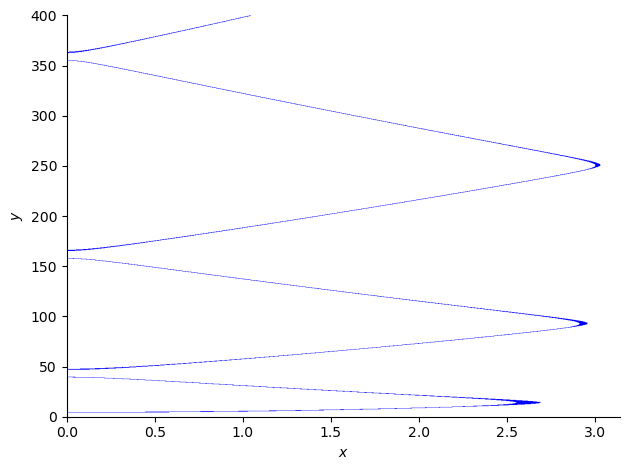

In [1]:
from sympy import symbols, plot_implicit
from sympy.parsing.sympy_parser import parse_expr
import numpy as np
d1=2
d2=2
a=0.5
x, y = symbols('x y')
expr_str = f'cos(x*2*{a}) - cos(sqrt(y)*2*{a}) - 2*{d1}*sin(sqrt(y)*2*{a})/(2*sqrt(y)) + ({d1**2}+{d2**2})*(cos(sqrt(y)*2*{a}) - 1)/(4*y)'
expr = parse_expr(expr_str)
plot = plot_implicit(expr, (x, 0, np.pi), (y, 0, 400), show=False)
plot.show()

In [2]:
import numpy as np    
from sympy import symbols, nsolve, cos, sin, sqrt, pi
from collections import defaultdict

def calculate_energy_levels(N, y1, y2, a, E_min, E_max):
    """
    计算给定参数下的能量级别(E值)
    参数:
        N: 系统参数
        y1, y2: 势能参数
        a: 系统参数
        E_min, E_max: 能量范围
    返回:
        字典，键是n值，值是对应的E值列表
    """
    N_0 = N if N % 2 == 0 else N - 1
    n_values = np.arange(int(N_0/2 + 1))
    E_sym = symbols('E')
    
    result_dict = {}  # 存储最终结果

    for n in n_values:
        equation = cos(2*a*sqrt(E_sym)) + y1*sin(2*a*sqrt(E_sym))/sqrt(E_sym) \
                  - (y1**2 + y2**2)*(cos(2*a*sqrt(E_sym))-1)/(4*E_sym) \
                  - cos(2*pi*n/N)
        
        solutions = []
        for E_guess in np.linspace(E_min + 0.1, E_max, 100):
            try:
                sol = float(nsolve(equation, E_sym, E_guess))
                if E_min <= sol <= E_max:
                    solutions.append(sol)
            except:
                continue
        
        # 去重并排序
        unique_solutions = sorted(list(set(solutions)))
        result_dict[n] = unique_solutions
    
    return result_dict

# 参数设置
N = 100
y1 = 2
y2 = 2
a = 0.5
E_min = 0
E_max = 400


energy_levels = calculate_energy_levels(N, y1, y2, a, E_min, E_max)

In [3]:
import numpy as np    
from sympy import symbols, nsolve, cos, sin, sqrt, pi
from collections import defaultdict
import os
from PIL import Image, ImageDraw, ImageFont
import imageio
import matplotlib.pyplot as plt

In [6]:
#改进，引进K
def calculate_energy_levels(N, y1, y2, a, E_min, E_max, k=10):
    """
    计算给定参数下的能量级别(E值)
    参数:
        N: 系统参数
        y1, y2: 势能参数
        a: 系统参数
        E_min, E_max: 能量范围
        k: 合并解的精度（小数点后k位相同则合并）
    返回:
        字典，键是n值，值是对应的E值列表
    """
    N_0 = N if N % 2 == 0 else N - 1
    n_values = np.arange(int(N_0/2 + 1))
    E_sym = symbols('E')
    
    result_dict = defaultdict(list)  # 存储最终结果

    for n in n_values:
        equation = cos(2*a*sqrt(E_sym)) + y1*sin(2*a*sqrt(E_sym))/sqrt(E_sym) \
                  - (y1**2 + y2**2)*(cos(2*a*sqrt(E_sym))-1)/(4*E_sym) \
                  - cos(2*pi*n/N)
        
        solutions = []
        for E_guess in np.linspace(E_min + 0.1, E_max, 100):
            try:
                sol = float(nsolve(equation, E_sym, E_guess, tol=1e-12))
                if E_min <= sol <= E_max:
                    solutions.append(sol)
            except:
                continue
        
        # 合并解（保留小数点后k位相同的唯一值）并排序
        merged_solutions = sorted(list({round(sol, k) for sol in solutions}))
        result_dict[n] = merged_solutions
    
    return dict(result_dict)


In [7]:
N = 100
y1 = 2
y2 = -2
a = 0.5
E_min = 0
E_max = 400
k=10
energy_levels=calculate_energy_levels(N, y1, y2, a, E_min, E_max, k=10)

E_array = []
n_array = []

for n, E_values in energy_levels.items():
    if E_values:  # 只处理有E值的情况
        E_array.extend(E_values)
        n_array.extend([n] * len(E_values))  # 每个E值对应一个n值


E_array = np.array(E_array)
n_array = np.array(n_array)
K_array=np.pi*n_array/(N*a)

new=dict(zip(E_array,K_array))
sorted_new = dict(sorted(new.items(), key=lambda item: item[0]))

In [ ]:
E_array = np.array(list(sorted_new.keys()))     # E数组
K_array = np.array(list(sorted_new.values()))   # K数组

plt.figure(figsize=(10, 6))
plt.scatter(E_array,K_array, s=30, alpha=0.7)  # 使用散点图
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Quantum Number (K)', fontsize=12)
plt.title('Energy Levels Distribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) 

#plt.xlim(max(0, E_min), min(E_max, max(E_array)*1.1))
#plt.ylim(min(n_array)-0.5, max(n_array)+0.5)

plt.tight_layout()
plt.show()

NameError: name 'sorted_new' is not defined

In [7]:
len(K_array),len(E_array)

(295, 295)

In [33]:
sorted_new = {
    n: E_list if isinstance(E_list, list) else [E_list]
    for n, E_list in sorted_new.items()
}

# 然后再过滤掉包含 0.0 的项
sorted_new = {
    n: E_list 
    for n, E_list in sorted_new.items() 
    if 0.0 not in E_list
}
print(len(sorted_new))
E_array = np.array(list(sorted_new.keys()))     # E数组
K_array = np.array(list(sorted_new.values()))   # K数组
print(len(E_array ),len(K_array))

288
288 288


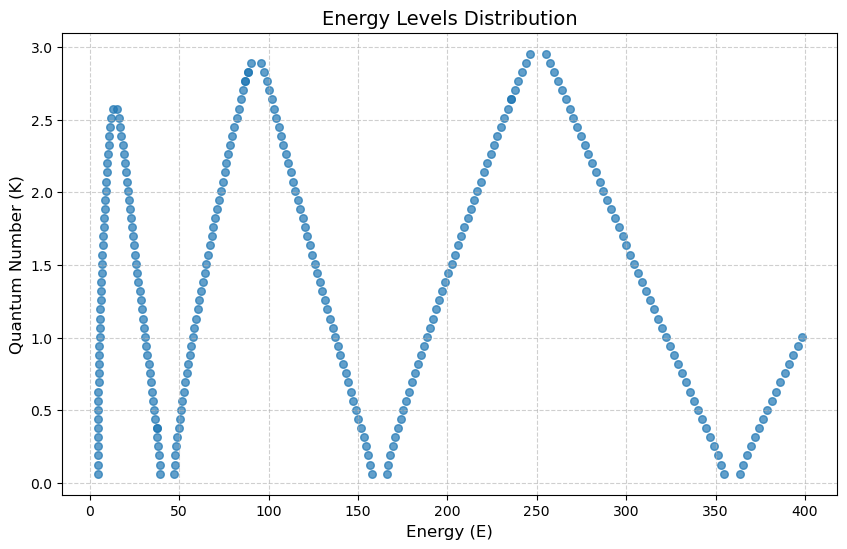

In [34]:
# 绘制图形
plt.figure(figsize=(10, 6))
plt.scatter(np.array(list(sorted_new.keys())),np.array(list(sorted_new.values())), s=30, alpha=0.7)  
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Quantum Number (K)', fontsize=12)
plt.title('Energy Levels Distribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

In [68]:
E_array = np.array(list(sorted_new.keys()))     # E数组
K_array = np.array(list(sorted_new.values()))   # K数组
K_array = np.array(list(sorted_new.values())).flatten()  # 转换为 (288,)
y_6=2*a*np.sin(2*K_array*a)
y_7=np.sin(2*a*E_array**0.5)*(a*E_array**(-0.5)+(y1/2-a*(y1**2+y2**2)/4)*E_array**(-1.5))
y_8=np.cos(2*a*E_array**0.5)*(a*y1*E_array**(-1)+((y1**2+y2**2)/4)*E_array**(-2))
y_9=((y1**2+y2**2)/4)*E_array**(-2)
Group_velocity=y_6/(y_7-y_8+y_9)
#Group_velocity=abs(Group_velocity)
len(Group_velocity),len(E_array)

(288, 288)

In [69]:
print("E_array shape:", E_array.shape)
print("Group_velocity shape:", Group_velocity.shape,K_array.shape)

E_array shape: (288,)
Group_velocity shape: (288,) (288,)


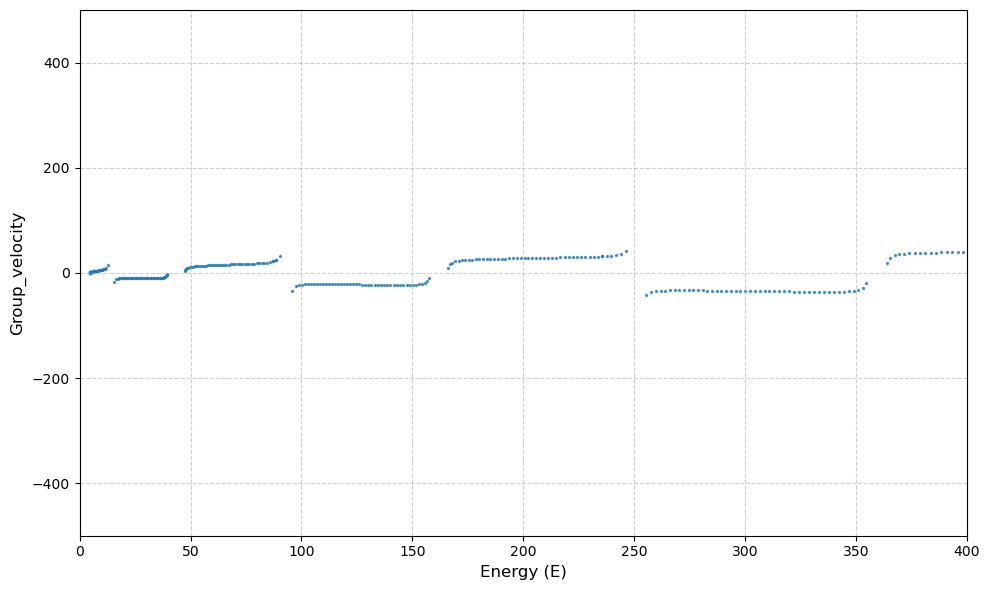

In [70]:
# 绘制图形
plt.figure(figsize=(10, 6))
plt.scatter(E_array,Group_velocity, s=2, alpha=0.7)  # 使用散点图
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Group_velocity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# 调整坐标轴范围
plt.xlim(0,400)
plt.ylim(-500,500)

# 显示图形
plt.tight_layout()
plt.show()